# Librerías

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys
import ast
import math
import pandas as pd 
from tqdm.auto import tqdm
from pandarallel import pandarallel

pandarallel.initialize(progress_bar=True) 
tqdm.pandas()

INFO: Pandarallel will run on 8 workers.
INFO: Pandarallel will use standard multiprocessing data transfer (pipe) to transfer data between the main process and workers.


/Users/melissa/Projects/GenAI-Science/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
sys.path.append('../src/')

In [4]:
from process_results.exists_url import apply_obtener_urls_con_progress, url_exists

# Constantes

In [5]:
PATH = '../data/results/'
PATH_OUT = '../data/analisis/'

BATCH_SIZE = 500

# Lectura de datos

In [56]:
df = pd.read_csv(PATH + 'results_gemini.csv')

# Procesamiento y exploración

In [57]:
df["references"] = df.references.apply(
    lambda x: str(x).replace('[', '').replace(']', '').split(','))

<Axes: >

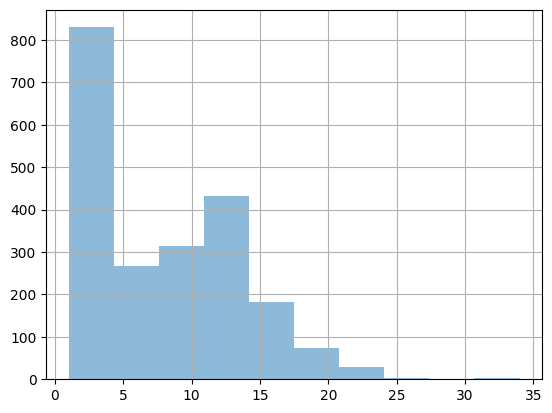

In [58]:
df['len_references'] = df['references'].apply(lambda x: len(x))
df['len_references'].hist(alpha = 0.5)

# Sacar links reales

In [ ]:
df["references_real"] = apply_obtener_urls_con_progress(df, col="references", max_workers_urls=32)

In [17]:
df.to_csv(PATH_OUT + 'results_gemini_links.csv', index = None) 

# Verificar links reales

## Lectura de datos

In [62]:
results_gemini = pd.read_csv(PATH_OUT + "results_gemini_links.csv")

## Verificar

In [63]:
results_gemini["references_real"] = results_gemini["references_real"].apply(
    lambda x: ast.literal_eval(x) if isinstance(x, str) else x
)

In [64]:
output_path = PATH_OUT + "processed/gemini_url_checks_progress.csv"

try:
    already_done = pd.read_csv(output_path)
    start_idx = len(already_done)
    print(f"Retomando desde fila {start_idx}")
except FileNotFoundError:
    already_done = None
    start_idx = 0

df_to_process = results_gemini.iloc[start_idx:].copy()
total_batches = math.ceil(len(df_to_process) / BATCH_SIZE)

for batch_num, batch_start in enumerate(range(0, len(df_to_process), BATCH_SIZE)):
    batch = df_to_process.iloc[batch_start : batch_start + BATCH_SIZE].copy()

    batch["url_check"] = batch["references_real"].progress_apply(lambda x: [url_exists(i) for i in x])

    # Primera vez: escribe con header. El resto: append sin header
    is_first_write = (batch_num == 0 and already_done is None)
    batch.to_csv(output_path, mode="w" if is_first_write else "a",
                 header=is_first_write, index=False)

    print(f"--> Batch {batch_num + 1}/{total_batches} guardado ({batch_start + len(batch)} filas totales)")

print("---> Proceso completado")

  0%|          | 0/500 [00:00<?, ?it/s]

--> Batch 1/5 guardado (500 filas totales)


  0%|          | 0/500 [00:00<?, ?it/s]

--> Batch 2/5 guardado (1000 filas totales)


  0%|          | 0/500 [00:00<?, ?it/s]

--> Batch 3/5 guardado (1500 filas totales)


  0%|          | 0/500 [00:00<?, ?it/s]

--> Batch 4/5 guardado (2000 filas totales)


  0%|          | 0/135 [00:00<?, ?it/s]

--> Batch 5/5 guardado (2135 filas totales)
---> Proceso completado


## Procesamiento extra

In [6]:
output_path = PATH_OUT + "processed/gemini_url_checks_progress.csv"

In [7]:

df = pd.read_csv(output_path)
df['url_check'] = df['url_check'].apply(lambda x: ast.literal_eval(x))

In [8]:
df['url_check']

0       [{'url': 'https://papers.neurips.cc/paper_file...
1       [{'url': 'https://medium.com/bcggamma/practice...
2       [{'url': 'https://jonathan-hui.medium.com/cave...
3       [{'url': 'https://research.aimultiple.com/ai-b...
4       [{'url': 'https://arxiv.org/abs/1606.06121', '...
                              ...                        
2130    [{'url': 'https://focuskeeper.co/glossary/what...
2131    [{'url': 'https://www.ibm.com/think/topics/ai-...
2132    [{'url': 'https://www.pinecone.io/learn/ai-hal...
2133    [{'url': 'https://www.pinecone.io/learn/ai-hal...
2134    [{'url': 'https://en.wikipedia.org/wiki/Reboun...
Name: url_check, Length: 2135, dtype: object

In [9]:
df['url_check'].explode().apply(lambda x: x['exists']).value_counts()

url_check
True     14755
False     1374
Name: count, dtype: int64

In [10]:
df['url_check'].explode().apply(lambda x: x['exists']).value_counts(True)

url_check
True     0.914812
False    0.085188
Name: proportion, dtype: float64

In [11]:
df.to_csv(output_path)

## Clasificar

In [7]:
df_gemini = pd.read_csv(output_path)
print(df_gemini.shape)

(2135, 9)


In [8]:
df_gemini["url_check"] = df_gemini["url_check"].apply(
    lambda x: ast.literal_eval(x)
)

In [9]:
from process_results.classify_urls import classify_url

In [10]:
df_gemini_revision = df_gemini.explode('url_check')

In [11]:
df_gemini_revision.url_check

0       {'url': 'https://papers.neurips.cc/paper_files...
0       {'url': 'https://machinesgonewrong.com/fairnes...
0       {'url': 'https://arxiv.org/abs/2007.06024', 'e...
0       {'url': 'http://fitelson.org/primer.pdf', 'exi...
0       {'url': 'https://www.researchgate.net/publicat...
                              ...                        
2134    {'url': 'https://www.sustainableconsumption.se...
2134    {'url': 'https://ukerc.rl.ac.uk/publications/w...
2134    {'url': 'https://blog.ucs.org/peter-oconnor/en...
2134    {'url': 'https://dictionary.cambridge.org/dict...
2134    {'url': 'https://en.wikipedia.org/wiki/Rebound...
Name: url_check, Length: 16129, dtype: object

In [12]:
df_gemini_revision = df_gemini_revision[df_gemini_revision.url_check.apply(lambda x: x['exists'])]
df_gemini_revision['clasificacion'] = df_gemini_revision['url_check'].apply(lambda x: x['url']).progress_apply(classify_url)

100%|██████████| 14755/14755 [00:25<00:00, 580.28it/s]


In [13]:
print(df_gemini_revision.shape)

(14755, 10)


In [14]:
df_gemini_revision['clasificacion'].iloc[0]

{'url': 'https://papers.neurips.cc/paper_files/paper/2022/file/d3222559698f41247261b7a6c2bbaedc-Paper-Conference.pdf',
 'peer_reviewed': 'sí',
 'confianza': 'baja',
 'razon': "Heurística: patrón '/paper[s]?/' en URL",
 'doi': ''}

In [15]:
# Nuevo
df_gemini_revision['clasificacion'].apply(lambda x: x['peer_reviewed']).value_counts()

clasificacion
no    12787
sí     1968
Name: count, dtype: int64

In [16]:
df_gemini_revision['clasificacion'].apply(lambda x: x['confianza']).value_counts()

clasificacion
baja     11855
alta      2833
media       67
Name: count, dtype: int64

In [22]:
df_gemini_revision.to_csv(PATH_OUT + '/processed/gemini_url_classify.csv')

# Análisis por tópico

In [97]:
df_gemini = pd.read_csv(PATH_OUT + '/processed/gemini_url_classify.csv')
df_gemini = df_gemini[[c for c in df_gemini.columns if 'Unnamed' not in c]]
print(df_gemini.shape)
df_gemini["url_check"] = df_gemini["url_check"].apply(
    lambda x: ast.literal_eval(x)
)
df_gemini["clasificacion"] = df_gemini["clasificacion"].apply(
    lambda x: ast.literal_eval(x)
)

(14755, 8)


In [98]:
prompts_topicos = pd.read_csv('../data/prompts_topic.csv')
prompts_topicos['topic'] = prompts_topicos['topic'].apply(lambda x: x.split('-'))
prompts_topicos = prompts_topicos.explode('topic')
prompts_topicos['topic'] = prompts_topicos['topic'].apply(lambda x: int(x.replace('.0', '')))

In [99]:
df_gemini = df_gemini.merge(prompts_topicos, on = 'prompt', how = 'left')

In [100]:
topics = pd.read_excel('../data/templates.xlsx', sheet_name='Topics')
topics['general topic'] = topics['general topic'].ffill()

In [101]:
prompts_topicos = prompts_topicos.merge(topics, left_on = 'topic', right_on='ID')

In [102]:
df_gemini = df_gemini.merge(topics, left_on = 'topic', right_on = 'ID', how = 'left')

In [105]:
df_gemini['Peer reviewed'] = df_gemini['clasificacion'].apply(lambda x: True if x['peer_reviewed'] == 'sí' else False)

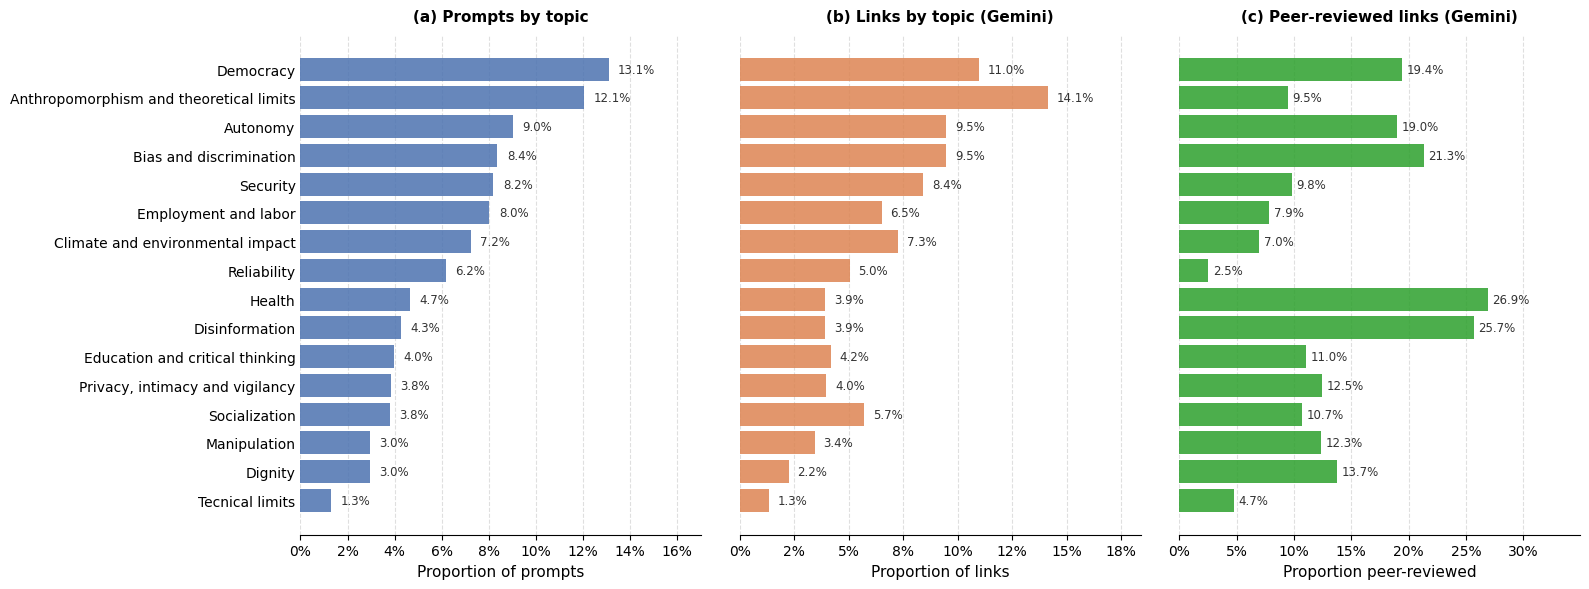

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick                                                 
                                                                                
# ── Datos ─────────────────────────────────────────────────────────────────      
prompts_per_topic = (                                                             
    prompts_topicos                                                               
    .drop_duplicates(subset=["prompt", "general topic"])                        
    .groupby("general topic")["prompt"]                                           
    .nunique()                                                                  
    .sort_values()                                                                
)                                                                               
prop_prompts = prompts_per_topic / prompts_per_topic.sum()                        
topic_order = prop_prompts.index                                                  
                                                                                
links_per_topic = df_gemini["general topic"].value_counts()                       
prop_links = (links_per_topic /                                                   
links_per_topic.sum()).reindex(topic_order).fillna(0)                             
                                                                                
df_gemini["peer_reviewed"] = df_gemini["clasificacion"].apply(                    
    lambda x: ast.literal_eval(x)["peer_reviewed"] if isinstance(x, str) else
x["peer_reviewed"]                                                                
)                                                                               
pr_by_topic = (                                                                   
    df_gemini.groupby("general topic")["peer_reviewed"]                         
    .apply(lambda x: (x == "sí").sum() / len(x))                                  
    .reindex(topic_order)
)                                                                                 
                                                                                
# ── Figura con sharey ─────────────────────────────────────────────────────      
plt.rcParams.update({"font.family": "sans-serif", "font.size": 10})             
                                                                                
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(16, 6), sharey=True)           
                                                                                
COLORS = ["#4C72B0", "#DD8452", "#2ca02c"]                                        
datasets = [                                                                      
      (ax1, prop_prompts.values, 'Proportion of prompts', '(a) Prompts by topic',   
  COLORS[0]),                                                                       
      (ax2, prop_links.values, 'Proportion of links', '(b) Links by topic (Gemini)',       
  COLORS[1]),                                                                       
      (ax3, pr_by_topic.values, 'Proportion peer-reviewed', '(c) Peer-reviewed links (Gemini)', COLORS[2]),                                                               
  ]                                                                                                
                                                                                
def style_ax(ax, first=False):                                                    
    for spine in ["top", "right", "left"]:
        ax.spines[spine].set_visible(False)                                       
    if not first:                                                               
        ax.spines["left"].set_visible(False)                                      
    ax.grid(axis="x", linestyle="--", alpha=0.4, zorder=0)                        
    ax.tick_params(axis="y", length=0)                                            
                                                                                
for i, (ax, values, xlabel, title, color) in enumerate(datasets):                 
    ax.barh(range(len(topic_order)), values, color=color, alpha=0.85, zorder=3) 
    ax.set_yticks(range(len(topic_order)))                                        
    ax.xaxis.set_major_formatter(mtick.PercentFormatter(xmax=1, decimals=0))    
    ax.set_xlabel(xlabel, fontsize=11)                                            
    ax.set_title(title, fontsize=11, fontweight="bold", pad=10)                   
    ax.set_xlim(0, max(values) * 1.30)                                            
    style_ax(ax, first=(i == 0))                                                  
    for patch, val in zip(ax.patches, values):                                    
        ax.text(patch.get_width() + 0.004, patch.get_y() + patch.get_height() / 2,
                f"{val:.1%}", va="center", ha="left", fontsize=8.5,               
color="#333333")                                                                  
                                                                                
ax1.set_yticklabels(topic_order, fontsize=10)                                     
                                                                                
plt.tight_layout(w_pad=2)                                                         
#plt.savefig(PATH_OUT + "topic_distribution_gemini.pdf", bbox_inches="tight", dpi=300)                                                                          
plt.show()       